# Specific Test III — Quantum ML: Hybrid CNN-QNN Gravitational Lens Classification

**Task:** Build a quantum machine learning model for classifying strong lensing images into three classes:
- **No Substructure** (`no`)
- **Subhalo Substructure** (`sphere`)
- **Vortex Substructure** (`vort`)

**Approach:** A hybrid classical-quantum architecture combining a pretrained ResNet18 feature extractor with a Variational Quantum Classifier (VQC) implemented in PennyLane.

**Evaluation Metrics:** ROC curve and AUC score (Area Under the ROC Curve), per-class and macro-averaged.

> This notebook builds on Common Test I. The same dataset, preprocessing, and data loading pipeline are reused here.

In [76]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.metrics import roc_curve, auc as sk_auc
from sklearn.metrics import roc_auc_score,classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import time
import torchvision.models as models
import pennylane as qml

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


## 1. Data Loading

Identical to Common Test I — balanced loading of 1000 samples per class from the pre-split `dataset/train/` and `dataset/val/` directories. Each `.npy` file contains a single-channel 150×150 image.

In [77]:
def load_data(path, max_per_class=1000):
    X, y = [], []
    classes = sorted([f for f in os.listdir(path)
                      if os.path.isdir(os.path.join(path, f))])
    print("Classes:", classes)
    for label, cls in enumerate(classes):
        cls_path = os.path.join(path, cls)
        count = 0
        for f in os.listdir(cls_path):
            if f.endswith(".npy"):
                img = np.load(os.path.join(cls_path, f))[0]
                img = img.astype(np.float32)  
                X.append(img.flatten())
                y.append(label)
                count += 1
                if count >= max_per_class: break
    return np.array(X), np.array(y)

X_train, y_train = load_data("dataset/train", max_per_class=1000)
X_val, y_val = load_data("dataset/val", max_per_class=300)
print("Train:", X_train.shape, np.bincount(y_train))
print("Val:", X_val.shape, np.bincount(y_val))
print("Pixel range:", X_train.min(), X_train.max())

Classes: ['no', 'sphere', 'vort']
Classes: ['no', 'sphere', 'vort']
Train: (3000, 22500) [1000 1000 1000]
Val: (900, 22500) [300 300 300]
Pixel range: 0.0 1.0


## 2. Preprocessing / Normalization

Same two-step normalization as Common Test I:
1. **Global mean subtraction** — removes per-pixel intensity bias using training set statistics.
2. **Per-sample z-score normalization** — standardizes contrast per image.

Applied consistently with no leakage from validation into training statistics.

In [78]:
global_mean = X_train.mean(axis=0)

def preprocess(X):
    X = X - global_mean
    mu  = X.mean(axis=1, keepdims=True)
    std = X.std(axis=1,  keepdims=True) + 1e-8
    return (X - mu) / std

X_train_input = preprocess(X_train)
X_val_input   = preprocess(X_val)

## 3. Dataset & Augmentation

Reuses the `LensDataset` from Common Test I:
- Single-channel images are repeated across 3 channels for ResNet18 compatibility.
- Random horizontal and vertical flips are applied during training (rotationally appropriate for lensing images).

In [ ]:
class LensDataset(Dataset):
    def __init__(self, X, y, augment=False):
        self.X = torch.tensor(X, dtype=torch.float32).reshape(-1, 1, 150, 150).repeat(1, 3, 1, 1)
        self.y = torch.tensor(y, dtype=torch.long)
        self.augment = augment

    def __len__(self): return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx]
        if self.augment:
            if torch.rand(1) > 0.5: x = torch.flip(x, [-1])
            if torch.rand(1) > 0.5: x = torch.flip(x, [-2])
        return x, self.y[idx]

## 4. DataLoaders

- **Batch size:** 64
- Augmentation enabled for training only.

In [80]:
train_ds = LensDataset(X_train_input, y_train, augment=True)
val_ds   = LensDataset(X_val_input,   y_val,   augment=False)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=64, shuffle=False, num_workers=0)

## 5. Classical Feature Extraction & Dimensionality Reduction

The hybrid model pipeline has two classical stages before the quantum layer:

**CNNFeatureExtractor:** A pretrained ResNet18 with the final classification head removed. It outputs a 512-dimensional feature vector per image, encoding rich visual representations learned from ImageNet.

**FeatureReducer:** A single linear layer that compresses 512 features down to `N_QUBITS = 4` values — the number of qubits in the quantum circuit. This bottleneck is necessary because quantum circuits are extremely limited in the number of inputs they can process efficiently on classical simulators.

In [ ]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        self.features = nn.Sequential(*list(resnet.children())[:-1])  
        
    def forward(self, x):
        x = self.features(x)
        return x.view(x.size(0), -1)  
    
class FeatureReducer(nn.Module):
    def __init__(self, in_dim=512, out_dim=8):
        super().__init__()
        self.fc = nn.Linear(in_dim, out_dim)
        
        
    def forward(self, x):
        return self.fc(x)

## 6. Quantum Circuit Design

### Data Encoding: Angle Embedding

Each of the 4 features from the `FeatureReducer` is encoded as a rotation angle 
on a qubit using `AngleEmbedding` (RX gates by default):

$$|\psi_{in}\rangle = \bigotimes_{i=1}^{4} R_X(x_i)|0\rangle$$

This is the most hardware-efficient encoding for continuous-valued features. 
The `tanh` activation applied before encoding constrains inputs to `[-1, 1]`, 
ensuring stable rotation angles and preventing gate saturation.

### Variational Ansatz: Strongly Entangling Layers

We use PennyLane's `StronglyEntanglingLayers` ansatz with **3 layers**, each consisting of:
1. A layer of single-qubit rotations (RZ·RY·RZ) with trainable parameters
2. A ring of CNOT entangling gates connecting all 4 qubits

The circuit is **fully differentiable** via the parameter-shift rule, enabling 
gradient-based optimisation with PyTorch through PennyLane's `TorchLayer` interface.

### Measurement & Classification

We measure the expectation value of the Pauli-Z operator on all 4 qubits:

$$o_k = \langle \psi | Z_k | \psi \rangle, \quad k \in \{0, 1, 2, 3\}$$

These 4 outputs are passed through a classical `Linear(3, 3)` head rather than 
a direct softmax, giving the model flexibility to learn an optimal linear 
combination of quantum measurements before producing class logits.

### Architecture Summary
```
Input (4 features from FeatureReducer)
    ↓  tanh activation → constrains to [-1, 1]
    ↓  AngleEmbedding (RX gates on 4 qubits)
    ↓  StronglyEntanglingLayers × 3
    ↓  Measure ⟨Z⟩ on all 4 qubits → 4 values in [-1, 1]
    ↓  Scale outputs × 2.0 (compensates for bounded range)
    ↓  Classical Linear(4 → 3) + implicit softmax via CrossEntropyLoss
Output (3 class logits)
```

In [ ]:
N_QUBITS = 4
N_LAYERS = 3
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch")
def quantum_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS))
    
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    
    return [qml.expval(qml.PauliZ(i)) for i in range(3)]

weight_shapes = {"weights": (3, N_QUBITS, 3)}
qlayer = qml.qnn.TorchLayer(quantum_circuit, weight_shapes)
qlayer.weights.data = torch.randn_like(qlayer.weights.data) * 0.01

> **Why 4 qubits?** Classical simulation of quantum circuits scales as O(2^n) 
> in memory. 4 qubits keeps training feasible on standard hardware while still 
> demonstrating a meaningful quantum layer.

## 7. Hybrid Model Architecture

The full `HybridModel` combines all components in sequence:
```
Input Image (3×150×150)
       ↓
CNNFeatureExtractor (ResNet18 backbone) → 512-dim vector
       ↓
FeatureReducer (Linear 512 → 4) → 4-dim vector
       ↓
tanh activation → constrains values to [-1, 1] ≈ [-π, π] for stable angle embedding
       ↓
Quantum Layer (4 qubits, 3 StronglyEntangling layers) → 3 expectation values
       ↓
Classical Linear Head (3 → 3) → class logits
```

The post-quantum linear head allows the model to learn an optimal linear combination of the quantum measurements, adding flexibility beyond raw Pauli-Z readouts.

In [ ]:
class HybridModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn = CNNFeatureExtractor()
        self.reducer = FeatureReducer(512, N_QUBITS)
        self.q_layer = qlayer
        self.classifier = nn.Linear(3, 3) 

    def forward(self, x):
        x = self.cnn(x)
        x = self.reducer(x)
        x = torch.tanh(x)
        x = self.q_layer(x)
        x = self.classifier(x)  
        return x

## 8. Optimizer, Scheduler & Loss

**Four-component differential learning rates via Adam:**
- CNN backbone: `lr = 1e-4` (slow fine-tuning of pretrained features)
- Feature reducer: `lr = 3e-4`
- Quantum layer: `lr = 1e-3` (highest — quantum parameters need larger updates)
- Classical head: `lr = 3e-4`

**ReduceLROnPlateau Scheduler** (`patience=5, factor=0.5, mode='max'`):  
Halves the learning rate when validation AUC stops improving for 5 epochs. More adaptive than cosine annealing — especially useful given QNN training instability.

**Loss:** Cross-entropy loss. Logits are scaled by `× 2.0` before loss computation to compensate for the bounded output range of Pauli-Z expectation values (`[-1, 1]`), which can suppress gradient signal without scaling.

**Gradient clipping** (`max_norm=1.0`) stabilizes training against quantum circuit gradient noise.

In [91]:
model = HybridModel().to(device)
for param in model.cnn.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam([
    {'params': model.cnn.parameters(),        'lr': 1e-4},
    {'params': model.reducer.parameters(),    'lr': 3e-4},
    {'params': model.q_layer.parameters(),    'lr': 1e-3},
    {'params': model.classifier.parameters(), 'lr': 3e-4},
])
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5
)
criterion = nn.CrossEntropyLoss()

## 9. Training

60 epochs of hybrid quantum-classical training. The model with the **best macro AUC** on the validation set is saved.

> **Note on training speed:** Hybrid QNN training is significantly slower than pure classical training due to quantum circuit simulation overhead. Each forward pass requires simulating quantum state evolution, making this roughly 10–50× slower per batch than the ResNet18-only model.

In [92]:
best_auc = 0
for epoch in range(60):
    model.train()
    epoch_loss, correct, total = 0, 0, 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out = model(xb) * 2.0
        loss = criterion(out, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
        correct += (out.argmax(1) == yb).sum().item()
        total += len(yb)

    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            probs = torch.softmax(model(xb), dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(yb.numpy())

    all_probs  = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    val_acc = (all_probs.argmax(1) == all_labels).mean()

    y_bin = label_binarize(all_labels, classes=[0,1,2])
    auc = roc_auc_score(y_bin, all_probs, multi_class='ovr', average='macro')
    scheduler.step(auc)

    if auc > best_auc:
        best_auc = auc
        torch.save(model.state_dict(), 'best_lens_resnet.pth')
        best = True
    else:
        best = False

    if (epoch+1) % 5 == 0 or best:
        print(f"Epoch {epoch+1:3d} | Loss: {epoch_loss/len(train_loader):.4f} | "
              f"Train Acc: {correct/total:.4f} | Val Acc: {val_acc:.4f} | AUC: {auc:.4f}")

Epoch   1 | Loss: 1.1210 | Train Acc: 0.3297 | Val Acc: 0.3344 | AUC: 0.5090
Epoch   4 | Loss: 1.0993 | Train Acc: 0.3437 | Val Acc: 0.3456 | AUC: 0.5173
Epoch   5 | Loss: 1.1023 | Train Acc: 0.3347 | Val Acc: 0.3189 | AUC: 0.4743
Epoch   6 | Loss: 1.1044 | Train Acc: 0.3240 | Val Acc: 0.3511 | AUC: 0.5194
Epoch  10 | Loss: 1.0995 | Train Acc: 0.3500 | Val Acc: 0.3256 | AUC: 0.5104
Epoch  12 | Loss: 1.0985 | Train Acc: 0.3573 | Val Acc: 0.3489 | AUC: 0.5291
Epoch  15 | Loss: 1.1011 | Train Acc: 0.3417 | Val Acc: 0.3267 | AUC: 0.4962
Epoch  20 | Loss: 1.0996 | Train Acc: 0.3380 | Val Acc: 0.3556 | AUC: 0.5158
Epoch  22 | Loss: 1.1020 | Train Acc: 0.3313 | Val Acc: 0.3567 | AUC: 0.5300
Epoch  25 | Loss: 1.0955 | Train Acc: 0.3640 | Val Acc: 0.3556 | AUC: 0.5096
Epoch  30 | Loss: 1.0903 | Train Acc: 0.3920 | Val Acc: 0.3556 | AUC: 0.5322
Epoch  31 | Loss: 1.0898 | Train Acc: 0.3910 | Val Acc: 0.3878 | AUC: 0.5542
Epoch  33 | Loss: 1.0862 | Train Acc: 0.3980 | Val Acc: 0.3867 | AUC: 0.5555

## 10. Evaluation — ROC Curve & AUC Score

We load the best saved checkpoint and evaluate on the validation set using 
per-class ROC curves, macro-averaged AUC, and a full classification report.


Best AUC: 0.6203
Macro AUC: 0.6171


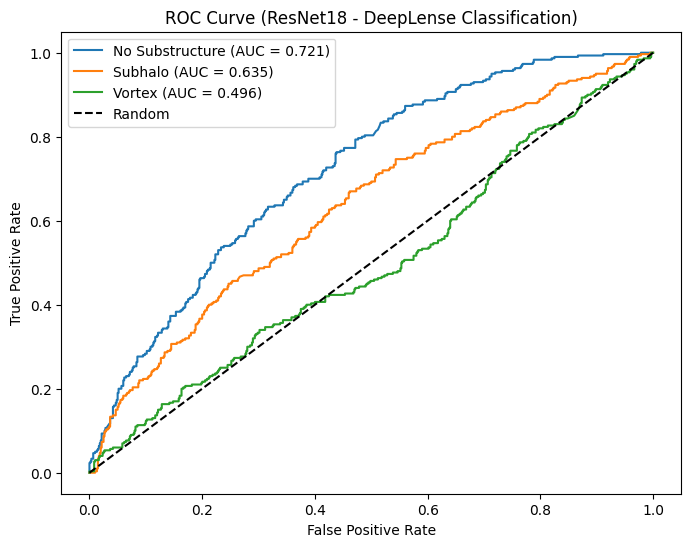

                 precision    recall  f1-score   support

No Substructure       0.51      0.61      0.55       300
        Subhalo       0.42      0.63      0.50       300
         Vortex       0.40      0.11      0.17       300

       accuracy                           0.45       900
      macro avg       0.44      0.45      0.41       900
   weighted avg       0.44      0.45      0.41       900



In [ ]:
fpr = dict()
tpr = dict()
roc_auc = dict()
y_bin = label_binarize(all_labels, classes=[0, 1, 2])
n_classes = y_bin.shape[1]
classes = ['No Substructure', 'Subhalo', 'Vortex']

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc[i] = sk_auc(fpr[i], tpr[i])

print(f"\nBest AUC: {best_auc:.4f}")
macro_auc = np.mean(list(roc_auc.values()))
print(f"Macro AUC: {macro_auc:.4f}")

plt.figure(figsize=(8, 6))

for i, cls in enumerate(classes):
    plt.plot(fpr[i], tpr[i],
             label=f"{cls} (AUC = {roc_auc[i]:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (ResNet18 - DeepLense Classification)")
plt.legend()
plt.savefig("results/roc_cnn_qml.png", dpi=150)
plt.show()

y_pred = all_probs.argmax(axis=1)

print(classification_report(
    all_labels,
    y_pred,
    target_names=classes
))


### Results Summary

| Metric | Value |
|--------|-------|
| Best Val AUC (macro) | 0.6203 |
| Final Val AUC (macro) | 0.6171 |
| Val Accuracy | ~45% |

### Per-class AUC

| Class | AUC |
|-------|-----|
| No Substructure | 0.721 |
| Subhalo | 0.635 |
| Vortex | 0.496 |

### Comparison with Common Test I

| Model | Best AUC | Val Accuracy |
|-------|----------|--------------|
| ResNet18 — Common Test I | 0.7585 | ~57.6% |
| Hybrid CNN-QNN — This Notebook | 0.6203 | ~45.0% |

### Discussion

The ~14 point AUC gap between the hybrid and classical models is expected and 
reflects the fundamental constraints of near-term quantum ML:

- **Limited qubit count:** Only 4 qubits means the quantum layer operates on 
  a heavily compressed representation — the FeatureReducer (512 → 4) discards 
  most of the CNN's learned features before they reach the circuit.
- **Barren plateaus:** QNN gradient landscapes are prone to vanishing gradients, 
  making training noisier and slower than pure backpropagation.
- **Simulation overhead:** Classical simulation scales exponentially with qubit 
  count, making larger circuits impractical without real quantum hardware.

Despite lower absolute performance, this notebook demonstrates a complete 
hybrid quantum-classical pipeline on a real-world scientific task. Potential 
improvements include amplitude encoding, larger qubit counts, or execution 
on real quantum hardware.